In [1]:
import torch
from torch import nn
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# __1. Xây dựng RNN cho dự đoán chuỗi thời gian__

## 1.1. Hidden state
Hidden state ($h_t$) là vector bộ nhớ mà RNN dùng để lưu thông tin các bước thời gian trước đó, giúp mạng nhớ ngữ cảnh
$$
h_t = \text{activation}(W\cdot x_t + U \cdot h_{t-1} + b)
$$
Với:
+ $W$: ma trận trọng số cho $x_t$
+ $U$: ma trận trọng số cho hidden state trước đó $h_{t-1}$
+ $b$: bias

```
x1        x2        x3        x4
 |         |         |         |
 v         v         v         v
[RNN]-->h1-->[RNN]-->h2-->[RNN]-->h3-->[RNN]-->h4 --> dự đoán
 ^
 h0 (sổ tay rỗng ban đầu, thường = 0)
```

In [3]:
rnn = nn.RNN(input_size=1, hidden_size=32, num_layers=1, batch_first=True)

In [4]:
x = torch.randn(4, 10, 1)
output, h_n = rnn(x) # h_n: hidden state ở bước cuối cùng

print(output.shape)  # (4, 10, 32) - hidden state ở TỪNG bước thời gian
print(h_n.shape)     # (1, 4, 32)  - hidden state CUỐI CÙNG (num_layers, batch, hidden)

torch.Size([4, 10, 32])
torch.Size([1, 4, 32])


## 1.2. Sliding window
Kỹ thuật `sliding window (cửa sổ trượt)` để biến 1 chuỗi thời gian dài thành các cặp dữ liệu (X, y) cho model học vì RNN/LSTM cần input dạng `"chuỗi con → giá trị tiếp theo"`, không thể học trực tiếp trên 1 chuỗi dài liên tục.

```
Chuỗi:  [ 0.0  0.3  0.6  0.8  0.9  1.0  ... ]

Cửa sổ 1: X = [0.0, 0.3, 0.6]   ->  y = 0.8
Cửa sổ 2: X = [0.3, 0.6, 0.8]   ->  y = 0.9
Cửa sổ 3: X = [0.6, 0.8, 0.9]   ->  y = 1.0
```

In [5]:
# Tạo sóng sine làm chuỗi thời gian
t = np.linspace(0, 100, 1000)
series = np.sin(t).astype(np.float32)

In [6]:
def make_windows(series, L):
  # Cửa sổ càng dài (L lớn) thì model càng “nhìn xa về quá khứ”, nhưng khó học hơn và tốn tính toán hơn. Với sóng sine, L cỡ 20-30 thường đủ bắt một chu kỳ.
  X, y = [], []
  for i in range(len(series) - L):
    X.append(series[i:i+L])
    y.append(series[i+L])
  X = np.array(X)[..., None]    # thêm chiều input_size=1 -> (mẫu, L, 1)
  y = np.array(y)[..., None]    # (mẫu, 1)
  return np.array(X), np.array(y)

In [7]:
X, y = make_windows(series, L=20)
print(X.shape, y.shape)   # (980, 20, 1)  (980, 1)

(980, 20, 1) (980, 1)


## 1.3. Tạo model và train mô hình

In [8]:
class SingleRNN(nn.Module):
  def __init__(self, hidden_size: int = 32):
    super().__init__()
    self.rnn_net = nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    out, h_n = self.rnn_net(x)
    last = out[:, -1, :] # Ta lấy out[:, -1, :] (hidden state bước cuối - bản tóm tắt đầy đủ nhất của cả cửa sổ) rồi cho Linear biến nó thành 1 con số.
    return self.fc(last) # (batch, 1)

In [9]:
model = SingleRNN(hidden_size=64).to(device)
loss_fn = nn.MSELoss() # dự đoán -> MSELoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 200
for epoch in range(EPOCHS):
  X_cuda = torch.from_numpy(X).to(device)
  y_cuda = torch.from_numpy(y).to(device)

  optimizer.zero_grad()
  y_pred = model(X_cuda)
  loss = loss_fn(y_pred, y_cuda)
  loss.backward()
  optimizer.step()
  if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.5f}")

Epoch 20, loss = 0.00525
Epoch 40, loss = 0.00188
Epoch 60, loss = 0.00055
Epoch 80, loss = 0.00013
Epoch 100, loss = 0.00006
Epoch 120, loss = 0.00003
Epoch 140, loss = 0.00002
Epoch 160, loss = 0.00002
Epoch 180, loss = 0.00001
Epoch 200, loss = 0.00001


## 1.4. Tại sao RNN hay quên khi chuỗi dài
+ Keyword: `Vanishing gradient`
+ Ở mỗi bước, khi lan truyền ngược, gradient bị nhân với trọng số $W_h$ và đạo hàm của `tanh` (luôn <= 1)
+ Nhân với 1 số <= 1 hàng chục, hàng trăm lần nên gradient dần trở về 0

Đây chính là lý do RNN cổ điển hiếm khi được dùng cho chuỗi dài trong thực tế, và là động lực trực tiếp để người ta phát minh ra `LSTM (Long Short-Term Memory)` - kiến trúc có “cổng” (gate) thông minh giữ ký ức xa lâu hơn. Đó đúng là nội dung bài tiếp theo!

# __2. LSTM__

## 2.1. Kiến trúc LSTM
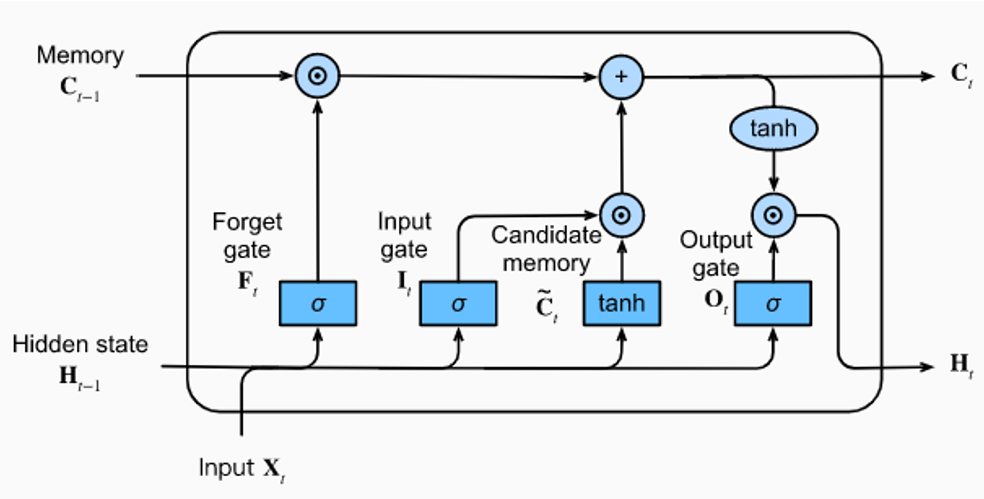

### 2.1.1. Ba cổng của LSTM
+ `Forget gate`: dùng để xác định thông tin nào trong quá khứ sẽ được bỏ thông qua hàm sigmoid: $f_t=σ(W_f\cdot [h_{t-1}, x_t]+ b_f)$. ($W_f$: ma trận trọng số của cổng quên).

+ `Input gate`: dùng để xác định thông tin nào sẽ được ghi lại
+ `Output gate`: tạo $h$ mới từ $c$ đã cập nhật

```
c_cũ  ──►[× forget]──►(+)──► c_mới ──►[× output]──► h_mới
                       ▲
              [input × ứng viên mới]
```

## 2.2. Cell state ($c$)
+ Là 1 cổng giữ lại thông tin xuyên suốt trong chuỗi thời gian (thông tin gần như không bị biến đổi ngoại trừ phép cộng/nhân nhẹ do các cổng điều khiển)
+ LSTM vẫn có các hidden state ($h$)

Tóm lại
+ Cell state ($c$): bộ nhớ dài hạn
+ Hidden state ($h$): bộ nhớ ngắn hạn

In [10]:
lstm = nn.LSTM(
    input_size=50, # số chiều của mỗi phần tử chuỗi (với text = chiều vector embedding của mỗi từ).
    hidden_size=128,
    batch_first=True,
)

In [11]:
x = torch.randn(4, 10, 50)
output, (h_n, c_n) = lstm(x)
print(output.shape)  # torch.Size([4, 10, 128]) - h tại MỌI bước
print(h_n.shape)     # torch.Size([1, 4, 128]) - h ở bước CUỐI
print(c_n.shape)     # torch.Size([1, 4, 128]) - cell state cuối

torch.Size([4, 10, 128])
torch.Size([1, 4, 128])
torch.Size([1, 4, 128])


In [12]:
class SentimentLSTM(nn.Module):
  def __init__(self, vocab_size, embed_dim=50, hidden_size=128):
    super().__init__()
    self.embed = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
    self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1) # để iutput ra prob của 1 từ
  def forward(self, x):
    emb = self.embed(x)
    out, (h_n, c_n) = self.lstm(emb)
    last = h_n[-1]
    logit = self.fc(last) # output thô (raw score) của layer cuối cùng, trước khi đi qua hàm activation (sigmoid/softmax). ví dụ: -2.3, 0.8, 5.1... (bất kỳ giá trị thực nào)
    prob = torch.sigmoid(logit)
    return prob.squeeze()

In [13]:
model = SentimentLSTM(vocab_size=20000)
# Giả lập 1 batch 2 câu, mỗi câu 6 từ (đã tokenize thành id)
batch = torch.randint(0, 20000, (2, 6))
probs = model(batch)                     # (2,)
# probs = torch.sigmoid(logits)             # xác suất positive 0..1
print(probs) # tensor([xác suất câu 1, xác suất câu 2])

tensor([0.5206, 0.5195], grad_fn=<SqueezeBackward0>)


In [14]:
def dem_thamso(model):
    return sum(p.numel() for p in model.parameters())

# __3. GRU__

+ GRU giống LSTM nhưng chỉ có 2 cổng `update gate` và `resset gate`
+ Nó gộp bộ nhớ dài hạn và bộ nhớ ngắn hạn vào 1 hidden state duy nhất
+ Nhanh hơn LSTM do ít tham số hơn, ít tốn bộ nhớ hơn nhưng lại có hiệu năng ngang LSTM ở `dữ liệu nhỏ`, phù hợp cho `edge devices`
+ LSTM không mất đi mà nó thường được sử dụng cho `dữ liệu dài`

In [15]:
class GRU(nn.Module):
  def __init__(self, vocab_size=20000, embed_dim=50, hidden_size=128):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_dim)
    self.gru = nn.GRU(embed_dim, hidden_size, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1)
  def forward(self, x):
    emb = self.embed(x)
    out, h_n = self.gru(emb)
    last = h_n[-1]
    logit = self.fc(last)
    prob = torch.sigmoid(logit)
    return prob.squeeze()

In [16]:
gru = GRU()
probs_gru = gru(batch)
print(probs_gru)

tensor([0.5112, 0.4315], grad_fn=<SqueezeBackward0>)


In [17]:
print(dem_thamso(gru))
print(dem_thamso(model))

1069249
1092289


# __4. Encoder, Decoder__

```
CHUỖI VÀO:   tôi     khỏe    <eos>
              |       |        |
           [Enc]-> [Enc]-> [Enc] ==> context vector (nén cả câu)
                                        |
                                        v
                                     [Dec]-> [Dec]-> [Dec]-> [Dec]
                                        |       |       |       |
CHUỖI RA:                             i      am     fine    <eos>
              (mỗi token sinh ra lại làm đầu vào cho bước kế tiếp)
```

Context vector (còn gọi thought vector) là một vector số cố định - ví dụ 256 hay 512 chiều - đại diện cho toàn bộ nghĩa của chuỗi vào. Cả câu dài mấy chục từ cũng bị “vắt” xuống thành đúng một vector này

## Chuẩn bị dữ liệu

In [18]:
from tokenizers import ByteLevelBPETokenizer

In [19]:
tokenizer = ByteLevelBPETokenizer()

In [20]:
corpus = [
    "hello world",
    "this is a sample sentence",
    "RNN cần tokenize đầu vào trước khi train",
    "Cái gì được nhỉ?"
]

In [21]:
tokenizer.train_from_iterator(
    corpus,
    vocab_size=8000,
    min_frequency=2,
    special_tokens=["<s>", "<pad>", "</s>", "<unk>", "<mask>"]
)

In [22]:
encoded = tokenizer.encode("abc xyz")
print(encoded.ids)
print(encoded.tokens)

[69, 70, 71, 225, 92, 93, 94]
['a', 'b', 'c', 'Ġ', 'x', 'y', 'z']


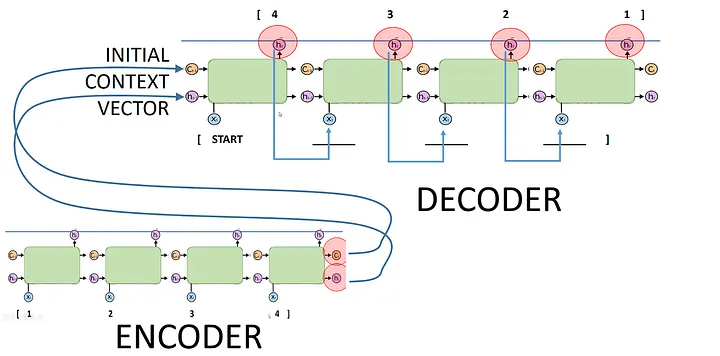

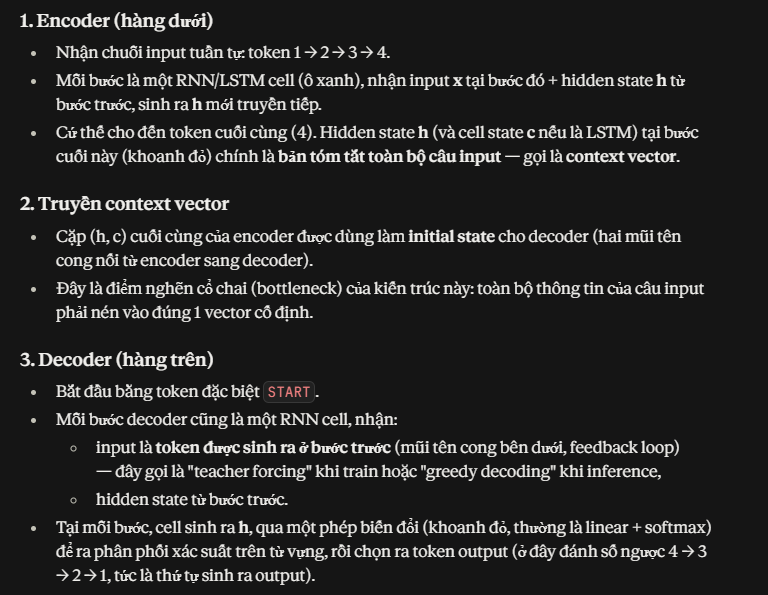

In [27]:
class Encoder(nn.Module):
  def __init__(self, vocab_size, emb_dim=50, hidden_size=128):
    super().__init__()
    self.emb = nn.Embedding(vocab_size, emb_dim)
    self.lstm = nn.LSTM(emb_dim, hidden_size, batch_first=True)
  def forward(self, x):
    emb = self.emb(x)
    out, (h_n, c_n) = self.lstm(emb) # không truyền state
    initial_vec = (h_n[-1].unsqueeze(0), c_n[-1].unsqueeze(0)) # Cặp (h, c) cuối cùng của encoder được dùng làm initial state cho decoder (hai mũi tên cong nối từ encoder sang decoder)
    return initial_vec

Encoder bạn trả về `h_n[-1], c_n[-1] → shape (batch, hidden_size)` — 2 chiều.

Nhưng nn.LSTM yêu cầu `h_0, c_0 có shape (num_layers * num_directions, batch, hidden_size)` — 3 chiều.

```python
# Sửa trong Encoder cho gọn:
initial_vec = (h_n[-1].unsqueeze(0), c_n[-1].unsqueeze(0))  # (1, batch, hidden_size)
```

In [35]:
class Decoder(nn.Module):
  def __init__(self, output_dim, emb_dim=50, hidden_size=128):
    super().__init__()
    self.emb = nn.Embedding(output_dim, emb_dim)
    self.lstm = nn.LSTM(emb_dim, hidden_size, batch_first=True)
    self.fc_out = nn.Linear(hidden_size, output_dim)
    self.output_dim = output_dim
  def forward(self, input, h_c):
    hidden, cell = h_c
    input = input.unsqueeze(1) # phải unsqueeze(1) trước khi qua embedding (hoặc sau, miễn ra đúng 3D): (batch,) -> (batch, 1)
    emb = self.emb(input) # (batch, 1, emb_dim)
    out, (h_n, c_n) = self.lstm(emb, (hidden, cell)) # truyền state
    out = self.fc_out(out.squeeze(1))
    return out, h_n, c_n

In [36]:
import random

In [37]:
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
  def forward(self, src, target, teacher_forcing_ratio=0.05):
    batch_size = src.shape[0]
    target_len = target.shape[1]
    target_vocab_size = self.decoder.output_dim
    outputs = torch.zeros(batch_size, target_len, target_vocab_size)
    hidden, cell = self.encoder(src)
    input = target[:, 0]

    for i in range(1, target_len):
      output, hidden, cell = self.decoder(input, hidden, cell)
      outputs[:, t, :] = output
      teacher_force = random.random() < teacher_forcing_ratio
      top1 = output.argmax(1)
      input = target[:, t] if teacher_force else top1

    return outputs

In [39]:
PAD_IDX = tokenizer.token_to_id("<pad>")
BOS_IDX = tokenizer.token_to_id("<s>")
EOS_IDX = tokenizer.token_to_id("</s>")
print(PAD_IDX, BOS_IDX, EOS_IDX)

1 0 2


In [40]:
encoded_corpus = [
    [BOS_IDX] + tokenizer.encode(sent).ids + [EOS_IDX]
    for sent in corpus
]
for ids in encoded_corpus:
    print(ids)

[0, 76, 73, 80, 80, 83, 225, 91, 83, 86, 80, 72, 2]
[0, 88, 264, 87, 225, 77, 87, 225, 69, 270, 69, 81, 84, 80, 73, 270, 261, 88, 261, 71, 73, 2]
[0, 54, 50, 50, 225, 71, 269, 82, 263, 83, 79, 261, 77, 94, 73, 271, 269, 89, 225, 90, 132, 259, 83, 272, 268, 254, 71, 225, 79, 264, 272, 69, 77, 82, 2]
[0, 39, 132, 99, 77, 225, 75, 132, 110, 271, 268, 101, 71, 225, 82, 76, 262, 236, 35, 2]


In [42]:
dataset = TextDataset(encoded_corpus)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

for src, trg in train_loader:
    print("src:", src)
    print("trg:", trg)
    break

src: tensor([[  0,  88, 264,  87, 225,  77,  87, 225,  69, 270,  69,  81,  84,  80,
          73, 270, 261,  88, 261,  71,  73,   2,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1],
        [  0,  54,  50,  50, 225,  71, 269,  82, 263,  83,  79, 261,  77,  94,
          73, 271, 269,  89, 225,  90, 132, 259,  83, 272, 268, 254,  71, 225,
          79, 264, 272,  69,  77,  82,   2]])
trg: tensor([[  0,  88, 264,  87, 225,  77,  87, 225,  69, 270,  69,  81,  84,  80,
          73, 270, 261,  88, 261,  71,  73,   2,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1],
        [  0,  54,  50,  50, 225,  71, 269,  82, 263,  83,  79, 261,  77,  94,
          73, 271, 269,  89, 225,  90, 132, 259,  83, 272, 268, 254,  71, 225,
          79, 264, 272,  69,  77,  82,   2]])


In [41]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch

class TextDataset(Dataset):
    def __init__(self, encoded_corpus):
        self.data = [torch.tensor(ids, dtype=torch.long) for ids in encoded_corpus]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.data[idx]   # src = trg (autoencoder)

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, trg_padded

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = tokenizer.get_vocab_size()
print(VOCAB_SIZE)   # số thật, có thể chỉ vài trăm

encoder = Encoder(vocab_size=VOCAB_SIZE)
decoder = Decoder(output_dim=VOCAB_SIZE)
model = Seq2Seq(encoder, decoder).to(device)

optimizer = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # bỏ qua token <PAD> khi tính loss

def train_epoch(dataloader):
    model.train()
    epoch_loss = 0
    for src, trg in dataloader:
        src, trg = src.to(device), trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)                      # (batch, trg_len, vocab_size)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim) # bỏ <SOS>, flatten
        trg_flat = trg[:, 1:].reshape(-1)              # bỏ <SOS>, flatten

        loss = loss_fn(output, trg_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # tránh exploding gradient
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

N_EPOCHS = 10
for epoch in range(N_EPOCHS):
    train_loss = train_epoch(train_loader)
    print(f"Epoch {epoch+1}: loss = {train_loss:.4f}")